# NYC Weather and Traffic Delay Prediction

This notebook builds an API-based data pipeline that combines NYC traffic volume data with weather data, stores the cleaned dataset in MySQL, explores congestion patterns, trains weather-aware delay-risk models, and exports Tableau-ready dashboard tables.


## 1. Environment Setup

Install dependencies if needed, then import the libraries used for API ingestion, data cleaning, visualization, modeling, MySQL storage, and Tableau exports.


In [2]:
# Optional: run once if these packages are missing from your notebook kernel.
%pip install openmeteo-requests requests-cache retry-requests


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [3]:
# Optional: run once if these packages are missing from your notebook kernel.
%pip install sqlalchemy pymysql python-dotenv


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


## 2. Weather API Ingestion

Pull historical weather observations from the Open-Meteo API for New York City. These records become the weather side of the traffic-delay analysis.


In [4]:
import openmeteo_requests

import pandas as pd
import requests_cache
from retry_requests import retry

# Setup the Open-Meteo API client with cache and retry on error
cache_session = requests_cache.CachedSession('.cache', expire_after = -1)
retry_session = retry(cache_session, retries = 5, backoff_factor = 0.2)
openmeteo = openmeteo_requests.Client(session = retry_session)

# Make sure all required weather variables are listed here
# The order of variables in hourly or daily is important to assign them correctly below
url = "https://archive-api.open-meteo.com/v1/archive"
params = {
	"latitude": 40.73061,
	"longitude": -73.935242,
	"start_date": "2020-01-01",
	"end_date": "2025-12-31",
	"daily": [
    "temperature_2m_mean",
    "temperature_2m_max",
    "temperature_2m_min",
    "precipitation_sum",   
    "sunrise",
    "sunset"
],
	"hourly": ["temperature_2m", "relative_humidity_2m", "dew_point_2m", "apparent_temperature", "precipitation", "rain", "snowfall", "snow_depth", "wind_speed_10m"],
	"timezone": "auto",
	"temperature_unit": "fahrenheit",
	"wind_speed_unit": "mph",
	"precipitation_unit": "inch",
}
responses = openmeteo.weather_api(url, params = params)

# Process first location. Add a for-loop for multiple locations or weather models
response = responses[0]
print(f"Coordinates: {response.Latitude()}°N {response.Longitude()}°E")
print(f"Elevation: {response.Elevation()} m asl")
print(f"Timezone: {response.Timezone()}{response.TimezoneAbbreviation()}")
print(f"Timezone difference to GMT+0: {response.UtcOffsetSeconds()}s")

# Process hourly data. The order of variables needs to be the same as requested.
hourly = response.Hourly()
hourly_temperature_2m = hourly.Variables(0).ValuesAsNumpy()
hourly_relative_humidity_2m = hourly.Variables(1).ValuesAsNumpy()
hourly_dew_point_2m = hourly.Variables(2).ValuesAsNumpy()
hourly_apparent_temperature = hourly.Variables(3).ValuesAsNumpy()
hourly_precipitation = hourly.Variables(4).ValuesAsNumpy()
hourly_rain = hourly.Variables(5).ValuesAsNumpy()
hourly_snowfall = hourly.Variables(6).ValuesAsNumpy()
hourly_snow_depth = hourly.Variables(7).ValuesAsNumpy()
hourly_wind_speed_10m = hourly.Variables(8).ValuesAsNumpy()

hourly_data = {"date": pd.date_range(
	start = pd.to_datetime(hourly.Time() + response.UtcOffsetSeconds(), unit = "s", utc = True),
	end =  pd.to_datetime(hourly.TimeEnd() + response.UtcOffsetSeconds(), unit = "s", utc = True),
	freq = pd.Timedelta(seconds = hourly.Interval()),
	inclusive = "left"
)}

hourly_data["temperature_2m"] = hourly_temperature_2m
hourly_data["relative_humidity_2m"] = hourly_relative_humidity_2m
hourly_data["dew_point_2m"] = hourly_dew_point_2m
hourly_data["apparent_temperature"] = hourly_apparent_temperature
hourly_data["precipitation"] = hourly_precipitation
hourly_data["rain"] = hourly_rain
hourly_data["snowfall"] = hourly_snowfall
hourly_data["snow_depth"] = hourly_snow_depth
hourly_data["wind_speed_10m"] = hourly_wind_speed_10m

hourly_dataframe = pd.DataFrame(data = hourly_data)

# Process daily data. The order of variables needs to be the same as requested.
daily = response.Daily()

daily_temperature_2m_mean = daily.Variables(0).ValuesAsNumpy()
daily_temperature_2m_max = daily.Variables(1).ValuesAsNumpy()
daily_temperature_2m_min = daily.Variables(2).ValuesAsNumpy()
daily_precipitation_sum = daily.Variables(3).ValuesAsNumpy()   # ✅ ADD THIS
daily_sunrise = daily.Variables(4).ValuesInt64AsNumpy()
daily_sunset = daily.Variables(5).ValuesInt64AsNumpy()

daily_data = {"date": pd.date_range(
	start = pd.to_datetime(daily.Time() + response.UtcOffsetSeconds(), unit = "s", utc = True),
	end =  pd.to_datetime(daily.TimeEnd() + response.UtcOffsetSeconds(), unit = "s", utc = True),
	freq = pd.Timedelta(seconds = daily.Interval()),
	inclusive = "left"
)}

daily_data["temperature_2m_mean"] = daily_temperature_2m_mean
daily_data["temperature_2m_max"] = daily_temperature_2m_max
daily_data["temperature_2m_min"] = daily_temperature_2m_min
daily_data["precipitation"] = daily_precipitation_sum
daily_data["sunrise"] = daily_sunrise
daily_data["sunset"] = daily_sunset
daily_dataframe = pd.DataFrame(data = daily_data)

hourly_dataframe.head()

Coordinates: 40.738136291503906°N -73.91488647460938°E
Elevation: 14.0 m asl
Timezone: b'America/New_York'b'GMT-4'
Timezone difference to GMT+0: -14400s


,date,temperature_2m,relative_humidity_2m,dew_point_2m,apparent_temperature,precipitation,rain,snowfall,snow_depth,wind_speed_10m
0,2020-01-01 00:00:00+00:00,39.829998,79.699532,34.070000,32.075100,0.0,0.0,0.0,0.0,10.088845
1,2020-01-01 01:00:00+00:00,38.209999,75.076363,31.010000,29.407892,0.0,0.0,0.0,0.0,11.428421
2,2020-01-01 02:00:00+00:00,35.779999,77.071312,29.299999,26.927099,0.0,0.0,0.0,0.0,10.963583
3,2020-01-01 03:00:00+00:00,34.790001,78.990501,28.940001,26.067801,0.0,0.0,0.0,0.0,10.535296
4,2020-01-01 04:00:00+00:00,34.160000,77.779877,27.950001,24.650108,0.0,0.0,0.0,0.0,12.081872


## 3. Traffic API Ingestion

Pull NYC traffic volume records directly from the NYC Open Data API. The project uses API ingestion instead of CSV files.


In [5]:
import requests
import pandas as pd

url = "https://data.cityofnewyork.us/resource/7ym2-wayt.json?$limit=50000"

response = requests.get(url)
data = response.json()

df_traffic = pd.DataFrame(data)

print(df_traffic.head())
print(df_traffic.columns)

  requestid    boro    yr  m  d hh  mm vol segmentid  \
0     12512  Queens  2013  3  7  4  15   5     55135   
1     12512  Queens  2013  3  7  4  30   8     55135   
2     12512  Queens  2013  3  7  4  45   8     55135   
3     12512  Queens  2013  3  7  5   0   7     55135   
4     12512  Queens  2013  3  7  5  15   9     55135   

                      wktgeom  street     fromst           tost direction  
0  POINT (1035363.4 185093.4)  122 PL  SUTTER AV  ROCKAWAY BLVD        SB  
1  POINT (1035363.4 185093.4)  122 PL  SUTTER AV  ROCKAWAY BLVD        SB  
2  POINT (1035363.4 185093.4)  122 PL  SUTTER AV  ROCKAWAY BLVD        SB  
3  POINT (1035363.4 185093.4)  122 PL  SUTTER AV  ROCKAWAY BLVD        SB  
4  POINT (1035363.4 185093.4)  122 PL  SUTTER AV  ROCKAWAY BLVD        SB  
Index(['requestid', 'boro', 'yr', 'm', 'd', 'hh', 'mm', 'vol', 'segmentid',
       'wktgeom', 'street', 'fromst', 'tost', 'direction'],
      dtype='str')


## 4. Clean, Align, and Merge

Standardize date and hour fields, merge traffic and weather records, and create the final modeling table.


In [6]:
hourly_dataframe["date"] = pd.to_datetime(hourly_dataframe["date"])
hourly_dataframe["date"] = hourly_dataframe["date"].dt.tz_localize(None)

hourly_dataframe["date_only"] = hourly_dataframe["date"].dt.date
hourly_dataframe["hour"] = hourly_dataframe["date"].dt.hour

In [7]:
df_traffic["date"] = pd.to_datetime(
    df_traffic["yr"].astype(str) + "-" +
    df_traffic["m"].astype(str) + "-" +
    df_traffic["d"].astype(str)
)

df_traffic["hour"] = df_traffic["hh"].astype(int)
df_traffic["vol"] = pd.to_numeric(df_traffic["vol"], errors="coerce")

df_traffic = df_traffic.dropna(subset=["date", "hour", "vol"])

In [8]:
df_traffic["date"] = pd.to_datetime(df_traffic["date"])
hourly_dataframe["date_only"] = pd.to_datetime(hourly_dataframe["date"].dt.date)

In [9]:
df_merged = pd.merge(
    df_traffic,
    hourly_dataframe,
    left_on=["date", "hour"],
    right_on=["date_only", "hour"],
    how="inner"
)

In [10]:
df_merged = df_merged.rename(columns={"date_x": "date"})

In [11]:
df_final = df_merged[[
    "date",
    "hour",
    "boro",
    "street",
    "fromst",
    "tost",
    "direction",
    "vol",
    "temperature_2m",
    "precipitation"
]].copy()

df_final = df_final.dropna()

In [12]:
# Preview the merged dataset before writing to MySQL.
display(df_final.head())
print(f"Final rows: {len(df_final):,}")


,date,hour,boro,street,fromst,tost,direction,vol,temperature_2m,precipitation
0,2023-11-15,20,Brooklyn,AVENUE J,East 80 Street,East 81 Street,EB,20,45.139999,0.0
1,2023-11-15,21,Brooklyn,AVENUE J,East 80 Street,East 81 Street,EB,15,45.950001,0.0
2,2023-11-15,21,Brooklyn,AVENUE J,East 80 Street,East 81 Street,EB,26,45.950001,0.0
3,2023-11-15,21,Brooklyn,AVENUE J,East 80 Street,East 81 Street,EB,23,45.950001,0.0
4,2023-11-15,21,Brooklyn,AVENUE J,East 80 Street,East 81 Street,EB,13,45.950001,0.0


Final rows: 8,776


## 5. MySQL Storage

Create/connect to the MySQL database and write the API-generated final table. This keeps Tableau and downstream analysis connected to database tables rather than local CSV files.


In [13]:
import os
from urllib.parse import quote_plus
from sqlalchemy import create_engine, text
from dotenv import load_dotenv

load_dotenv()

MYSQL_USER = os.getenv("MYSQL_USER", "root")
MYSQL_PASSWORD = quote_plus(os.getenv("MYSQL_PASSWORD", "your_password"))
MYSQL_HOST = os.getenv("MYSQL_HOST", "localhost")
MYSQL_PORT = os.getenv("MYSQL_PORT", "3306")
MYSQL_DATABASE = os.getenv("MYSQL_DATABASE", "weather_traffic")

# Connect to MySQL server, not a specific database yet
server_engine = create_engine(
    f"mysql+pymysql://{MYSQL_USER}:{MYSQL_PASSWORD}@{MYSQL_HOST}:{MYSQL_PORT}/",
    pool_pre_ping=True
)

with server_engine.connect() as conn:
    conn.execute(text(f"CREATE DATABASE IF NOT EXISTS {MYSQL_DATABASE}"))
    conn.commit()

# Now connect to the database you created
engine = create_engine(
    f"mysql+pymysql://{MYSQL_USER}:{MYSQL_PASSWORD}@{MYSQL_HOST}:{MYSQL_PORT}/{MYSQL_DATABASE}",
    pool_pre_ping=True
)



In [14]:
df_final.to_sql(
    "weather_traffic_full",
    con=engine,
    if_exists="replace",
    index=False
)

8776

## 6. Exploratory Data Analysis


In [15]:
import matplotlib.pyplot as plt

eda_df = df_final.copy()
eda_df["date"] = pd.to_datetime(eda_df["date"])
eda_df["vol"] = pd.to_numeric(eda_df["vol"], errors="coerce")
eda_df["temperature_2m"] = pd.to_numeric(eda_df["temperature_2m"], errors="coerce")
eda_df["precipitation"] = pd.to_numeric(eda_df["precipitation"], errors="coerce")
eda_df["day_of_week"] = eda_df["date"].dt.day_name()
eda_df["month"] = eda_df["date"].dt.to_period("M").astype(str)
eda_df["is_raining"] = eda_df["precipitation"] > 0

print(f"Rows: {eda_df.shape[0]:,}")
print(f"Columns: {eda_df.shape[1]:,}")
print(f"Date range: {eda_df['date'].min().date()} to {eda_df['date'].max().date()}")
display(eda_df.head())

Rows: 8,776
Columns: 13
Date range: 2020-01-26 to 2024-06-07


,date,hour,boro,street,fromst,tost,direction,vol,temperature_2m,precipitation,day_of_week,month,is_raining
0,2023-11-15,20,Brooklyn,AVENUE J,East 80 Street,East 81 Street,EB,20,45.139999,0.0,Wednesday,2023-11,False
1,2023-11-15,21,Brooklyn,AVENUE J,East 80 Street,East 81 Street,EB,15,45.950001,0.0,Wednesday,2023-11,False
2,2023-11-15,21,Brooklyn,AVENUE J,East 80 Street,East 81 Street,EB,26,45.950001,0.0,Wednesday,2023-11,False
3,2023-11-15,21,Brooklyn,AVENUE J,East 80 Street,East 81 Street,EB,23,45.950001,0.0,Wednesday,2023-11,False
4,2023-11-15,21,Brooklyn,AVENUE J,East 80 Street,East 81 Street,EB,13,45.950001,0.0,Wednesday,2023-11,False


In [16]:
overview = pd.DataFrame({
    "dtype": eda_df.dtypes.astype(str),
    "missing_count": eda_df.isna().sum(),
    "missing_pct": (eda_df.isna().mean() * 100).round(2),
    "unique_values": eda_df.nunique()
})

display(overview)
print(f"Duplicate rows: {eda_df.duplicated().sum():,}")
display(eda_df[["vol", "temperature_2m", "precipitation", "hour"]].describe().T)

,dtype,missing_count,missing_pct,unique_values
date,datetime64[us],0,0.0,161
hour,int64,0,0.0,24
boro,str,0,0.0,5
street,str,0,0.0,70
fromst,str,0,0.0,65
tost,str,0,0.0,61
direction,str,0,0.0,4
vol,int64,0,0.0,677
temperature_2m,float32,0,0.0,662
precipitation,float32,0,0.0,45


Duplicate rows: 656


,count,mean,std,min,25%,50%,75%,max
vol,8776.0,112.942457,161.516707,0.000000,17.000000,61.000000,142.000000,1295.000000
temperature_2m,8776.0,55.568874,15.686083,14.450001,44.059998,55.580002,67.910004,90.500000
precipitation,8776.0,0.005353,0.028202,0.000000,0.000000,0.000000,0.000000,0.661417
hour,8776.0,11.311418,6.895309,0.000000,5.000000,11.000000,17.000000,23.000000


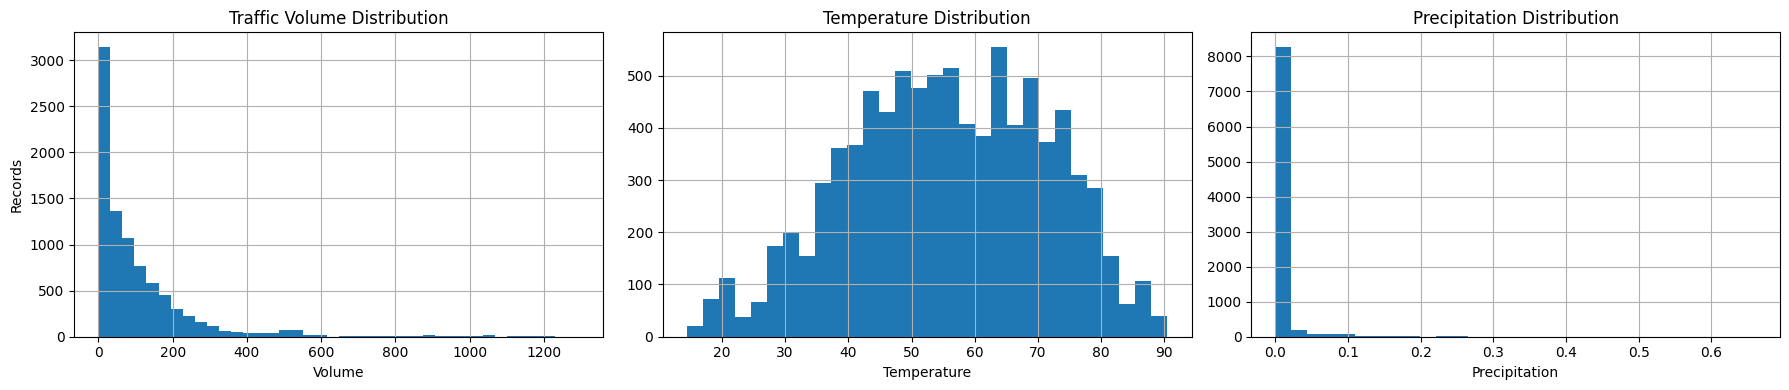

In [17]:
fig, axes = plt.subplots(1, 3, figsize=(18, 4))

eda_df["vol"].hist(bins=40, ax=axes[0])
axes[0].set_title("Traffic Volume Distribution")
axes[0].set_xlabel("Volume")
axes[0].set_ylabel("Records")

eda_df["temperature_2m"].hist(bins=30, ax=axes[1])
axes[1].set_title("Temperature Distribution")
axes[1].set_xlabel("Temperature")

eda_df["precipitation"].hist(bins=30, ax=axes[2])
axes[2].set_title("Precipitation Distribution")
axes[2].set_xlabel("Precipitation")

plt.tight_layout()
plt.show()

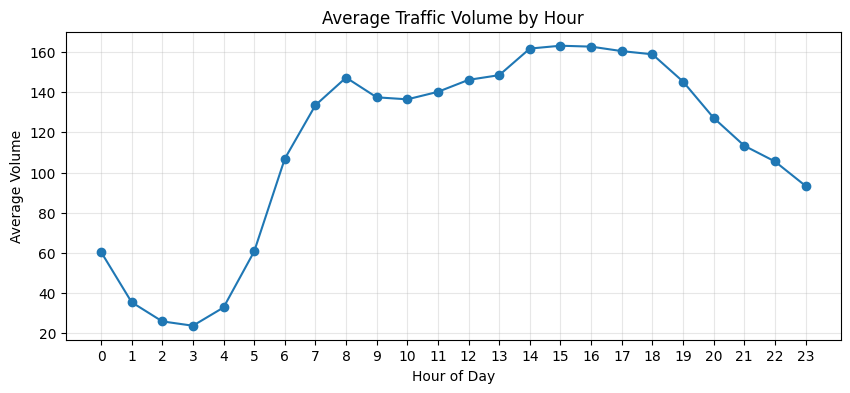

,hour,vol
15,15,163.081232
16,16,162.629526
14,14,161.665738
17,17,160.399433
18,18,158.818713
13,13,148.441489
8,8,147.229111
12,12,146.107612
19,19,145.252226
11,11,140.148936


In [18]:
hourly_pattern = eda_df.groupby("hour", as_index=False)["vol"].mean()

plt.figure(figsize=(10, 4))
plt.plot(hourly_pattern["hour"], hourly_pattern["vol"], marker="o")
plt.title("Average Traffic Volume by Hour")
plt.xlabel("Hour of Day")
plt.ylabel("Average Volume")
plt.xticks(range(0, 24))
plt.grid(alpha=0.3)
plt.show()

display(hourly_pattern.sort_values("vol", ascending=False).head(10))

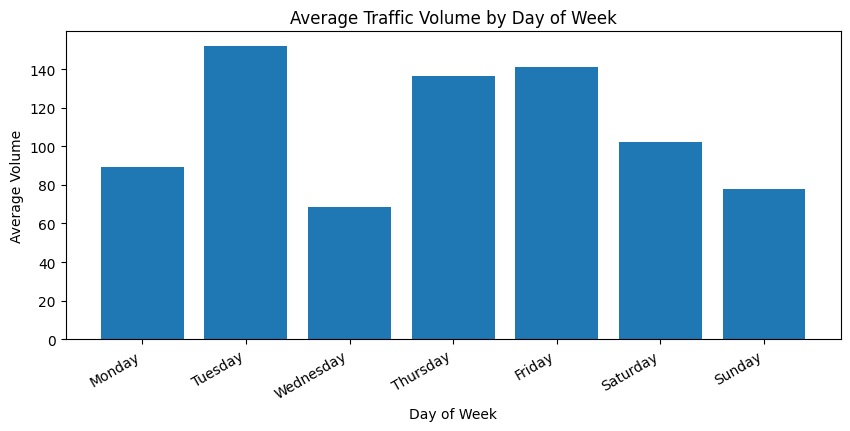

,day_of_week,vol
0,Monday,89.317797
1,Tuesday,151.917834
2,Wednesday,68.658200
3,Thursday,136.588881
4,Friday,141.247605
5,Saturday,102.047809
6,Sunday,78.065217


In [19]:
day_order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
day_pattern = eda_df.groupby("day_of_week")["vol"].mean().reindex(day_order).reset_index()

plt.figure(figsize=(10, 4))
plt.bar(day_pattern["day_of_week"], day_pattern["vol"])
plt.title("Average Traffic Volume by Day of Week")
plt.xlabel("Day of Week")
plt.ylabel("Average Volume")
plt.xticks(rotation=30, ha="right")
plt.show()

display(day_pattern)

,records,avg_volume,median_volume,max_volume
boro,,,,
Brooklyn,2780,150.629496,79.0,1295
Manhattan,1306,135.843798,127.0,569
Staten Island,315,130.711111,133.0,362
Queens,2586,94.013921,34.0,795
Bronx,1789,61.893236,37.0,263


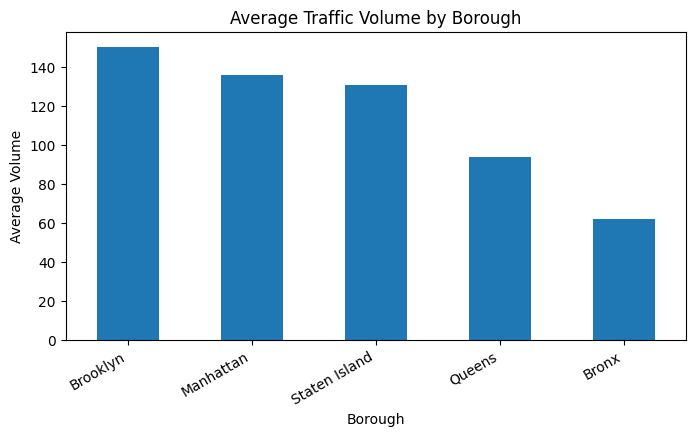

In [20]:
boro_summary = (
    eda_df.groupby("boro")
    .agg(records=("vol", "size"), avg_volume=("vol", "mean"), median_volume=("vol", "median"), max_volume=("vol", "max"))
    .sort_values("avg_volume", ascending=False)
)

display(boro_summary)
boro_summary["avg_volume"].plot(kind="bar", figsize=(8, 4), title="Average Traffic Volume by Borough")
plt.xlabel("Borough")
plt.ylabel("Average Volume")
plt.xticks(rotation=30, ha="right")
plt.show()

In [21]:
street_summary = (
    eda_df.groupby(["boro", "street"])
    .agg(records=("vol", "size"), avg_volume=("vol", "mean"), max_volume=("vol", "max"))
    .query("records >= 5")
    .sort_values("avg_volume", ascending=False)
    .head(15)
)

display(street_summary)

records  avg_volume  max_volume
boro      street                                                           
Brooklyn  BELT PARKWAY                          105  841.133333        1295
          BROOKLYN QUEENS EXPRESSWAY            105  752.076190        1066
Queens    HOOK CREEK BRIDGE                     374  378.390374         682
Manhattan EAST 58 STREET                         23  377.478261         569
Brooklyn  HAMILTON AVENUE                       105  272.180952         740
          GOWANUS EP WB EN HUGH CAREY TNNL      105  270.209524         598
Manhattan AVENUE OF THE AMERICAS                105  263.800000         418
Queens    NORTH CONDUIT AVENUE                   46  252.826087         795
Brooklyn  HAMILTON AVENUE BRIDGE                 71  234.521127         590
          CROPSEY AVENUE                         77  216.740260         371
Queens    BROOKLYN QUEENS EXPRESSWAY             20  215.750000         463
Manhattan 5 AVENUE                              105  214.057143         332
          7 AVENUE                              105  207.676190         309
Bronx     EAST TREMONT AVENUE                    69  183.304348         243
Brooklyn  ATLANTIC AVENUE                       105  178.780952         326

,records,avg_volume,median_volume,avg_temperature,avg_precipitation
is_raining,,,,,
False,7646,113.653675,60.0,55.736092,0.000000
True,1130,108.130088,73.0,54.437401,0.041572


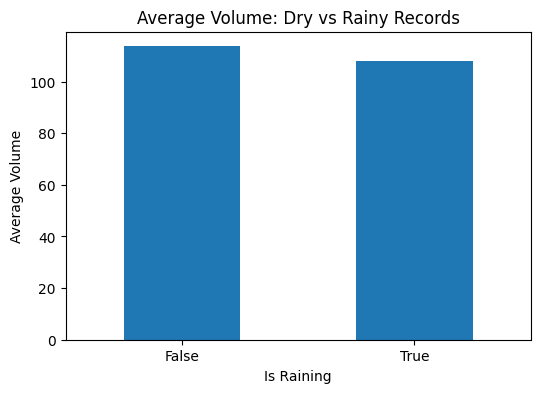

In [22]:
weather_summary = eda_df.groupby("is_raining").agg(
    records=("vol", "size"),
    avg_volume=("vol", "mean"),
    median_volume=("vol", "median"),
    avg_temperature=("temperature_2m", "mean"),
    avg_precipitation=("precipitation", "mean")
)

display(weather_summary)
weather_summary["avg_volume"].plot(kind="bar", figsize=(6, 4), title="Average Volume: Dry vs Rainy Records")
plt.xlabel("Is Raining")
plt.ylabel("Average Volume")
plt.xticks(rotation=0)
plt.show()

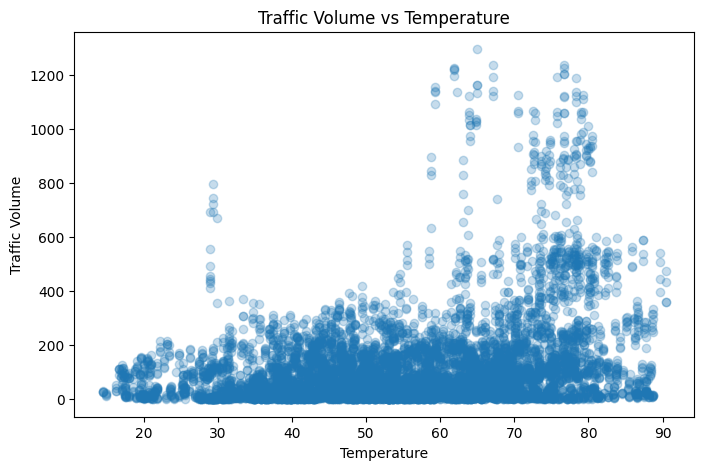

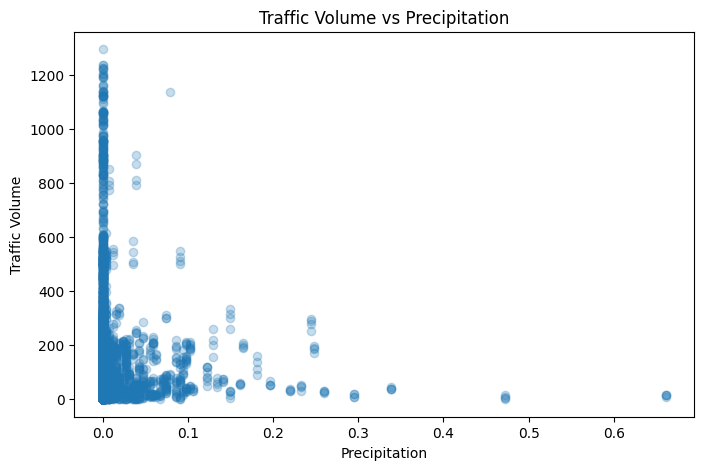

,vol,temperature_2m,precipitation,hour
vol,1.000000,0.303326,-0.022166,0.183205
temperature_2m,0.303326,1.000000,-0.004705,0.194206
precipitation,-0.022166,-0.004705,1.000000,0.000879
hour,0.183205,0.194206,0.000879,1.000000


In [23]:
plt.figure(figsize=(8, 5))
plt.scatter(eda_df["temperature_2m"], eda_df["vol"], alpha=0.25)
plt.title("Traffic Volume vs Temperature")
plt.xlabel("Temperature")
plt.ylabel("Traffic Volume")
plt.show()

plt.figure(figsize=(8, 5))
plt.scatter(eda_df["precipitation"], eda_df["vol"], alpha=0.25)
plt.title("Traffic Volume vs Precipitation")
plt.xlabel("Precipitation")
plt.ylabel("Traffic Volume")
plt.show()

display(eda_df[["vol", "temperature_2m", "precipitation", "hour"]].corr())

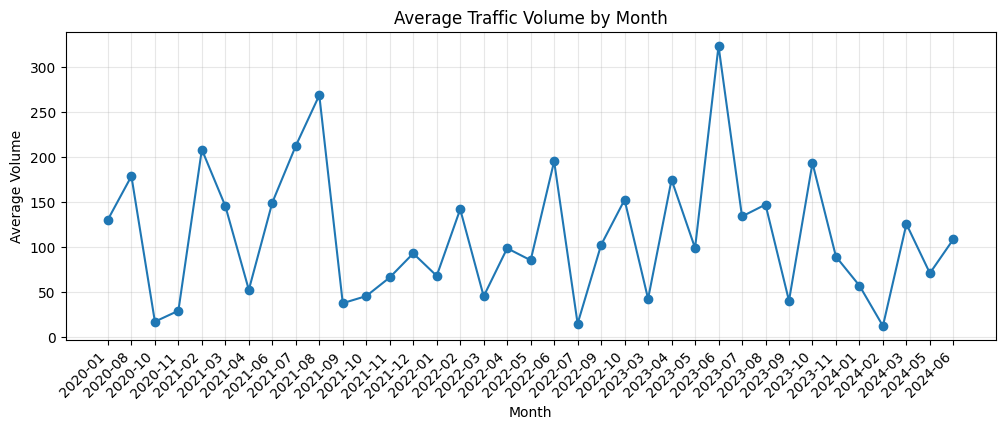

,month,vol
25,2023-05,99.156522
26,2023-06,323.051322
27,2023-07,134.166667
28,2023-08,147.313131
29,2023-09,40.676190
30,2023-10,193.382812
31,2023-11,89.619048
32,2024-01,57.485714
33,2024-02,12.756757
34,2024-03,125.752381


In [24]:
monthly_pattern = eda_df.groupby("month", as_index=False)["vol"].mean()

plt.figure(figsize=(12, 4))
plt.plot(monthly_pattern["month"], monthly_pattern["vol"], marker="o")
plt.title("Average Traffic Volume by Month")
plt.xlabel("Month")
plt.ylabel("Average Volume")
plt.xticks(rotation=45, ha="right")
plt.grid(alpha=0.3)
plt.show()

display(monthly_pattern.tail(12))

In [25]:
if "engine" in globals():
    sql_check = pd.read_sql("""
        SELECT
            boro,
            COUNT(*) AS records,
            AVG(vol) AS avg_volume,
            AVG(temperature_2m) AS avg_temperature,
            AVG(precipitation) AS avg_precipitation
        FROM weather_traffic_full
        GROUP BY boro
        ORDER BY avg_volume DESC
    """, con=engine)
    display(sql_check)
else:
    print("MySQL engine is not defined yet. Run the database connection cell first to query from MySQL.")

,boro,records,avg_volume,avg_temperature,avg_precipitation
0,Brooklyn,2780,150.6295,58.024989,0.001684
1,Manhattan,1306,135.8438,51.967320,0.003777
2,Staten Island,315,130.7111,37.370000,0.000550
3,Queens,2586,94.0139,56.877413,0.009798
4,Bronx,1789,61.8932,55.694299,0.006624


### Initial EDA Takeaways

1. TEMPORAL DRIVERS (strongest signal)
- Hour of day: peaks at 8 AM and 2–6 PM. Lowest overnight at 2-3 AM. Classic commuter pattern.
- Day of week: Tuesday and Friday highest. Weekend volumes drop significantly vs weekday average.
- Month: high volatility, no clean seasonality. Spike in Jun–Jul 2023.

2. WEATHER EFFECTS (moderate signal)
- Temperature: strong positive correlation. High volumes cluster at 60–80°F; near-zero volume below 30°F.
- Precipitation: minimal suppression effect. Dry avg vs rainy avg — statistically small difference. Most records have zero precipitation (zero-inflated dist.).

3. GEOGRAPHIC VARIATION (moderate signal)
- Brooklyn > Manhattan > Staten Island > Queens > Bronx.
- Bronx volume is ~58% lower than Brooklyn — may reflect sensor coverage differences rather than true traffic gap.

4. DATA QUALITY FLAGS
- Traffic volume is right-skewed: median << mean. Many near-zero records (overnight, holidays, outages).
- Monthly time series shows irregular near-zero months

## 7. ML Pipeline: Precipitation and Traffic Delay Regression

Research focus: **How do weather conditions impact traffic delays and transportation patterns in NYC?**

The source data does not include measured travel-time delay, so this pipeline creates a stronger delay proxy from traffic volume behavior. It compares each record with normal traffic for the same street, direction, day, and hour, then combines abnormal volume, percentile-based spikes, and precipitation pressure into `delay_minutes`.


### Research Questions

1. What is the relationship between precipitation and estimated delay time in NYC traffic records?
2. Does adding weather improve delay-time regression after the model already knows traffic volume, time, and location?
3. Which boroughs and rain intensities show the largest transportation pattern changes?
4. What tables support the required dashboards: live predictions, city comparison, and A/B results?


In [26]:
ml_df = eda_df.copy()

import seaborn as sns
sns.set_theme(style="whitegrid")

ml_df["rush_hour"] = ml_df["hour"].between(7, 10) | ml_df["hour"].between(16, 19)
ml_df["rain_intensity"] = pd.cut(
    ml_df["precipitation"],
    bins=[-0.001, 0, 0.05, 0.15, float("inf")],
    labels=["none", "light", "moderate", "heavy"]
)

baseline_cols = ["boro", "street", "fromst", "tost", "direction", "day_of_week", "hour"]
traffic_baseline = (
    ml_df.groupby(baseline_cols)["vol"]
    .agg(
        expected_volume="median",
        p75_volume=lambda x: x.quantile(0.75),
        p90_volume=lambda x: x.quantile(0.90),
        volume_iqr=lambda x: x.quantile(0.75) - x.quantile(0.25),
        baseline_std="std",
        baseline_records="size"
    )
    .reset_index()
)

ml_df = ml_df.merge(traffic_baseline, on=baseline_cols, how="left")
ml_df = ml_df[ml_df["expected_volume"] > 0].copy()

ml_df["volume_ratio"] = ml_df["vol"] / ml_df["expected_volume"]
ml_df["volume_delta"] = ml_df["vol"] - ml_df["expected_volume"]
ml_df["delay_index"] = ml_df["volume_ratio"]

fallback_spread = ml_df["expected_volume"].clip(lower=1) * 0.25
spread = ml_df["volume_iqr"].where(ml_df["volume_iqr"] > 0, fallback_spread)
ml_df["congestion_score"] = (ml_df["volume_delta"] / spread).replace([float("inf"), -float("inf")], 0).fillna(0)

ml_df["is_moderate_congestion"] = ml_df["vol"] >= ml_df["p75_volume"]
ml_df["is_volume_spike"] = ml_df["vol"] >= ml_df["p90_volume"]
ml_df["weather_pressure"] = (
    (ml_df["precipitation"] > 0).astype(int)
    + (ml_df["precipitation"] >= 0.05).astype(int)
    + (ml_df["precipitation"] >= 0.15).astype(int)
)

ml_df["delay_score"] = (
    ml_df["congestion_score"].clip(lower=0)
    + 0.25 * ml_df["is_moderate_congestion"].astype(int)
    + 0.50 * ml_df["is_volume_spike"].astype(int)
    + 0.25 * ml_df["weather_pressure"]
)

# Delay-time proxy: each delay-score point represents about 10 minutes of estimated congestion delay.
ml_df["delay_minutes"] = (ml_df["delay_score"].clip(lower=0, upper=4) * 10).round(2)
ml_df["delay_level"] = pd.cut(
    ml_df["delay_minutes"],
    bins=[-0.001, 5, 15, 30, float("inf")],
    labels=["Low", "Moderate", "High", "Severe"]
)

active_hours_df = ml_df[ml_df["hour"].between(5, 23)].copy()

print(f"Rush-hour rows: {len(active_hours_df):,}")
print(f"Average estimated delay minutes: {active_hours_df['delay_minutes'].mean():.2f}")
print(f"Average precipitation: {active_hours_df['precipitation'].mean():.3f}")
display(active_hours_df[[
    "date", "hour", "boro", "street", "vol", "expected_volume", "volume_ratio",
    "volume_delta", "congestion_score", "is_volume_spike", "weather_pressure",
    "delay_score", "delay_minutes", "delay_level", "temperature_2m", "precipitation", "rain_intensity"
]].head())


Rush-hour rows: 6,833
Average estimated delay minutes: 6.19
Average precipitation: 0.005


,date,hour,boro,street,vol,expected_volume,volume_ratio,volume_delta,congestion_score,is_volume_spike,weather_pressure,delay_score,delay_minutes,delay_level,temperature_2m,precipitation,rain_intensity
0,2023-11-15,20,Brooklyn,AVENUE J,20,20.0,1.000000,0.0,0.000000,True,0,0.750000,7.50,Moderate,45.139999,0.0,none
1,2023-11-15,21,Brooklyn,AVENUE J,15,19.0,0.789474,-4.0,-0.432432,False,0,0.000000,0.00,Low,45.950001,0.0,none
2,2023-11-15,21,Brooklyn,AVENUE J,26,19.0,1.368421,7.0,0.756757,True,0,1.506757,15.07,High,45.950001,0.0,none
3,2023-11-15,21,Brooklyn,AVENUE J,23,19.0,1.210526,4.0,0.432432,False,0,0.432432,4.32,Low,45.950001,0.0,none
4,2023-11-15,21,Brooklyn,AVENUE J,13,19.0,0.684211,-6.0,-0.648649,False,0,0.000000,0.00,Low,45.950001,0.0,none


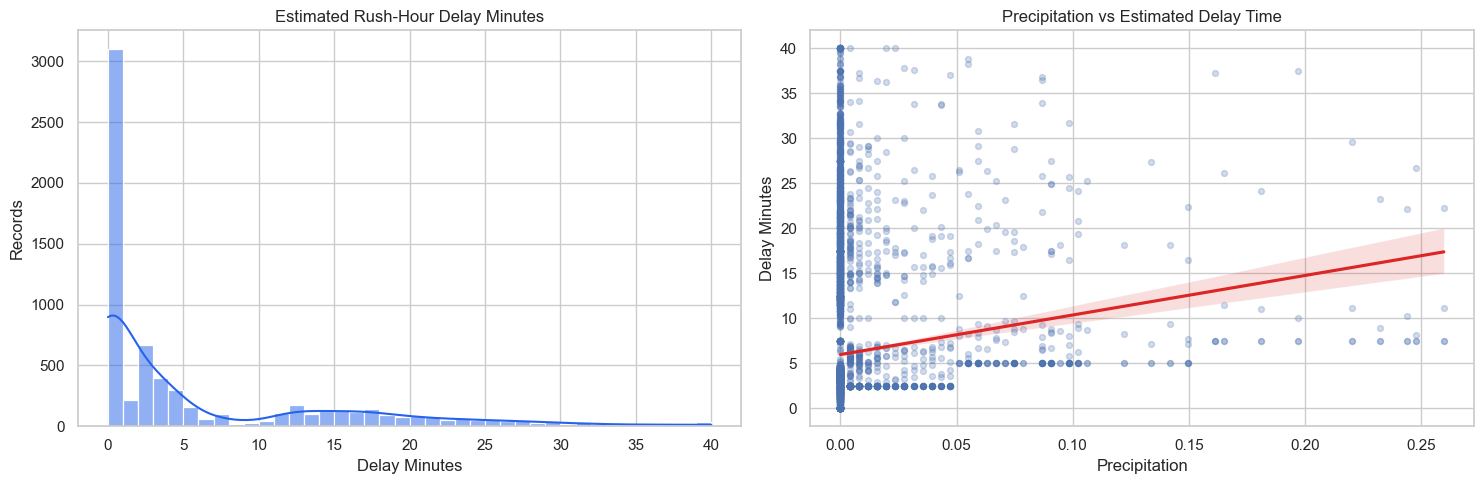

In [27]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

sns.histplot(active_hours_df["delay_minutes"], bins=40, kde=True, ax=axes[0], color="#2563eb")
axes[0].set_title("Estimated Rush-Hour Delay Minutes")
axes[0].set_xlabel("Delay Minutes")
axes[0].set_ylabel("Records")

sns.regplot(
    data=active_hours_df,
    x="precipitation",
    y="delay_minutes",
    scatter_kws={"alpha": 0.25, "s": 18},
    line_kws={"color": "#dc2626"},
    ax=axes[1]
)
axes[1].set_title("Precipitation vs Estimated Delay Time")
axes[1].set_xlabel("Precipitation")
axes[1].set_ylabel("Delay Minutes")

plt.tight_layout()
plt.show()


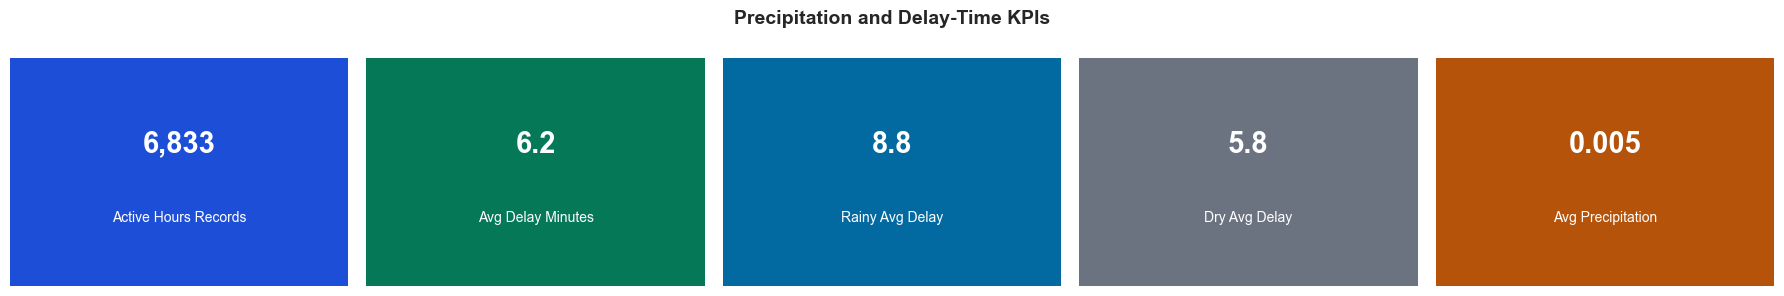

In [28]:
rainy_mask = active_hours_df["is_raining"].astype(str).str.lower().eq("true")
dry_mask = ~rainy_mask

kpi_values = {
    "Active Hours Records": f"{len(active_hours_df):,}",
    "Avg Delay Minutes": f"{active_hours_df['delay_minutes'].mean():.1f}",
    "Rainy Avg Delay": f"{active_hours_df.loc[rainy_mask, 'delay_minutes'].mean():.1f}" if rainy_mask.any() else "N/A",
    "Dry Avg Delay": f"{active_hours_df.loc[dry_mask, 'delay_minutes'].mean():.1f}" if dry_mask.any() else "N/A",
    "Avg Precipitation": f"{active_hours_df['precipitation'].mean():.3f}"
}

fig, axes = plt.subplots(1, len(kpi_values), figsize=(18, 3))
card_colors = ["#1d4ed8", "#047857", "#0369a1", "#6b7280", "#b45309"]

for ax, (label, value), color in zip(axes, kpi_values.items(), card_colors):
    ax.set_facecolor(color)
    ax.text(0.5, 0.62, value, ha="center", va="center", fontsize=21, color="white", fontweight="bold")
    ax.text(0.5, 0.30, label, ha="center", va="center", fontsize=10, color="white")
    ax.set_xticks([])
    ax.set_yticks([])
    for spine in ax.spines.values():
        spine.set_visible(False)

plt.suptitle("Precipitation and Delay-Time KPIs", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()


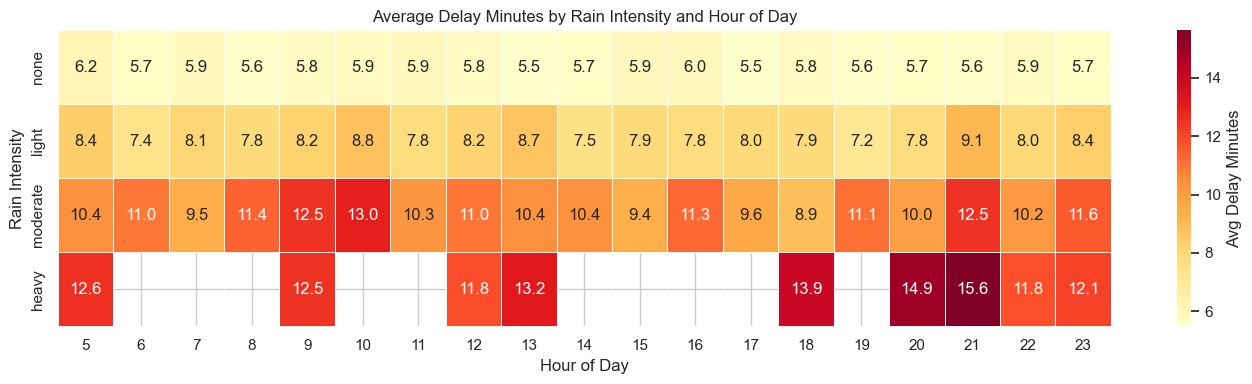

In [29]:
rain_time_heatmap = active_hours_df.pivot_table(
    index="rain_intensity",
    columns="hour",
    values="delay_minutes",
    aggfunc="mean"
)

# Ensure logical rain intensity order
rain_time_heatmap = rain_time_heatmap.reindex(["none", "light", "moderate", "heavy"])

plt.figure(figsize=(14, 4))
sns.heatmap(
    rain_time_heatmap,
    annot=True,
    fmt=".1f",
    cmap="YlOrRd",
    linewidths=0.5,
    cbar_kws={"label": "Avg Delay Minutes"}
)
plt.title("Average Delay Minutes by Rain Intensity and Hour of Day")
plt.xlabel("Hour of Day")
plt.ylabel("Rain Intensity")
plt.tight_layout()
plt.show()

In [30]:
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestRegressor
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

baseline_features = ["vol", "hour", "boro", "street", "direction", "day_of_week"]
weather_features = baseline_features + ["temperature_2m", "precipitation", "is_raining", "rain_intensity"]
target = "delay_minutes"

categorical_cleanup_cols = ["boro", "street", "direction", "day_of_week", "is_raining", "rain_intensity"]
for col in categorical_cleanup_cols:
    active_hours_df[col] = active_hours_df[col].astype("object").where(active_hours_df[col].notna(), "missing").astype(str)

numeric_lookup = ["vol", "hour", "temperature_2m", "precipitation"]

target_diagnostics = pd.DataFrame({
    "metric": ["mean", "std", "min", "max"],
    "delay_minutes": [
        active_hours_df[target].mean(),
        active_hours_df[target].std(),
        active_hours_df[target].min(),
        active_hours_df[target].max()
    ]
})
print("Delay target diagnostics:")
display(target_diagnostics)
display(active_hours_df[["date", "hour", "boro", "street", "vol", target]].head(10))

correlation_rows = []
for col in numeric_lookup:
    correlation_rows.append({
        "feature": col,
        "correlation_with_delay_minutes": active_hours_df[[col, target]].corr().iloc[0, 1]
    })
feature_correlations = pd.DataFrame(correlation_rows).sort_values(
    "correlation_with_delay_minutes",
    key=lambda series: series.abs(),
    ascending=False
)
print("Numeric feature-target correlations:")
display(feature_correlations)

def build_regression_model(feature_cols):
    numeric_features = [col for col in feature_cols if col in numeric_lookup]
    categorical_features = [col for col in feature_cols if col not in numeric_features]

    preprocessor = ColumnTransformer([
        ("num", Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler())
        ]), numeric_features),
        ("cat", Pipeline([
            ("encoder", OneHotEncoder(handle_unknown="ignore"))
        ]), categorical_features)
    ])

    return Pipeline([
        ("preprocessor", preprocessor),
        ("model", RandomForestRegressor(n_estimators=150, max_depth=12, min_samples_leaf=15, min_samples_split=30, max_features="sqrt", random_state=42))
    ])

X_train, X_test, y_train, y_test = train_test_split(
    active_hours_df[weather_features],
    active_hours_df[target],
    test_size=0.25,
    random_state=42
)

baseline_model = build_regression_model(baseline_features)
weather_model = build_regression_model(weather_features)

baseline_model.fit(X_train[baseline_features], y_train)
weather_model.fit(X_train[weather_features], y_train)

def evaluate_predictions(name, features, ab_group, pred):
    return {
        "model": name,
        "features": features,
        "mae": mean_absolute_error(y_test, pred),
        "rmse": mean_squared_error(y_test, pred) ** 0.5,
        "r2": r2_score(y_test, pred),
        "ab_group": ab_group
    }

mean_prediction = pd.Series(y_train.mean(), index=y_test.index)
baseline_pred = pd.Series(
    baseline_model.predict(X_test[baseline_features]).clip(min=0),
    index=y_test.index
)
weather_pred = pd.Series(
    weather_model.predict(X_test[weather_features]).clip(min=0),
    index=y_test.index
)

model_results = pd.DataFrame([
    evaluate_predictions("mean_delay_benchmark", "train_mean_only", "Benchmark: mean", mean_prediction),
    evaluate_predictions("baseline_volume_time_location", "volume_time_location", "A: volume baseline", baseline_pred),
    evaluate_predictions("precipitation_aware", "volume_time_location_weather_precipitation", "B: precipitation-aware", weather_pred)
])

display(model_results)

pred_compare = X_test.copy()
pred_compare["actual_delay_minutes"] = y_test
pred_compare["mean_prediction"] = mean_prediction
pred_compare["baseline_prediction"] = baseline_pred
pred_compare["precipitation_prediction"] = weather_pred
display(pred_compare[["vol", "hour", "boro", "precipitation", "rain_intensity", "actual_delay_minutes", "mean_prediction", "baseline_prediction", "precipitation_prediction"]].head())


Delay target diagnostics:


,metric,delay_minutes
0,mean,6.192576
1,std,8.966431
2,min,0.000000
3,max,40.000000


,date,hour,boro,street,vol,delay_minutes
0,2023-11-15,20,Brooklyn,AVENUE J,20,7.50
1,2023-11-15,21,Brooklyn,AVENUE J,15,0.00
2,2023-11-15,21,Brooklyn,AVENUE J,26,15.07
3,2023-11-15,21,Brooklyn,AVENUE J,23,4.32
4,2023-11-15,21,Brooklyn,AVENUE J,13,0.00
5,2023-11-15,22,Brooklyn,AVENUE J,17,15.83
6,2023-11-15,22,Brooklyn,AVENUE J,15,1.67
7,2023-11-15,22,Brooklyn,AVENUE J,14,0.00
8,2023-11-15,22,Brooklyn,AVENUE J,8,0.00
9,2023-11-15,23,Brooklyn,AVENUE J,11,2.67


Numeric feature-target correlations:


,feature,correlation_with_delay_minutes
3,precipitation,0.106925
0,vol,0.030227
2,temperature_2m,-0.012055
1,hour,-0.005798


,model,features,mae,rmse,r2,ab_group
0,mean_delay_benchmark,train_mean_only,7.039028,8.768877,-0.003081,Benchmark: mean
1,baseline_volume_time_location,volume_time_location,6.953016,8.694896,0.013773,A: volume baseline
2,precipitation_aware,volume_time_location_weather_precipitation,6.976216,8.692920,0.014222,B: precipitation-aware


,vol,hour,boro,precipitation,rain_intensity,actual_delay_minutes,mean_prediction,baseline_prediction,precipitation_prediction
1603,22,11,Bronx,0.0,none,12.50,6.314118,6.682044,6.032120
7446,1123,18,Brooklyn,0.0,none,13.04,6.314118,6.431116,6.392848
534,3,23,Brooklyn,0.0,none,0.00,6.314118,4.810375,4.801850
7419,915,11,Brooklyn,0.0,none,15.46,6.314118,6.269433,6.021873
3265,109,13,Bronx,0.0,none,0.00,6.314118,6.377086,5.817064


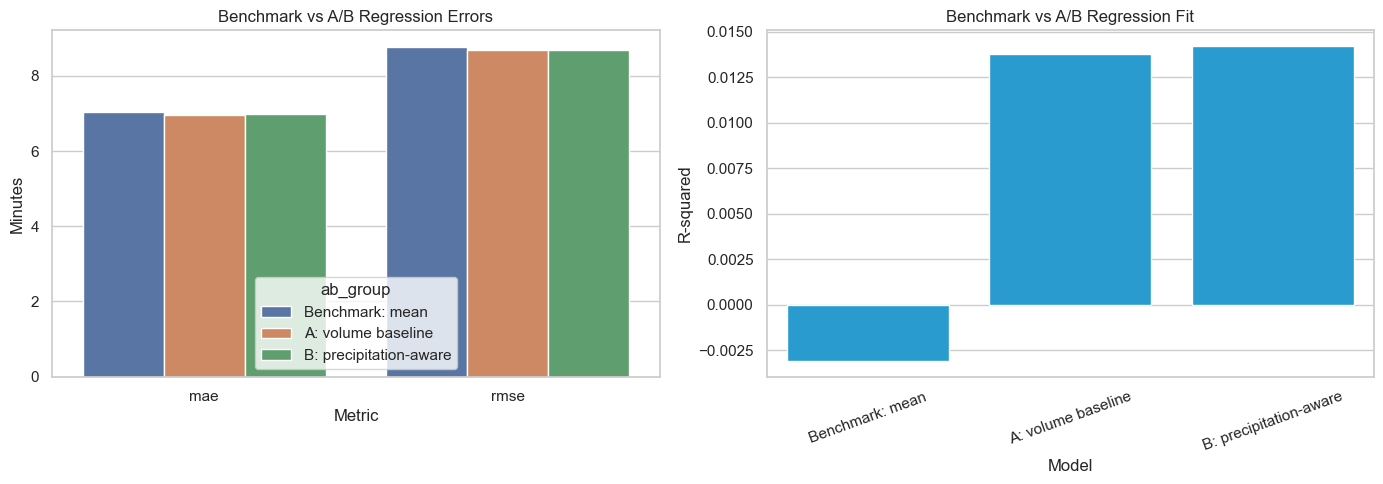

,precipitation_model_minus_volume_baseline
mae,0.023201
rmse,-0.001976
r2,0.000448


In [31]:
model_results_long = model_results.melt(
    id_vars=["model", "features", "ab_group"],
    value_vars=["mae", "rmse", "r2"],
    var_name="metric",
    value_name="score"
)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
error_metrics = model_results_long[model_results_long["metric"].isin(["mae", "rmse"])]
sns.barplot(data=error_metrics, x="metric", y="score", hue="ab_group", ax=axes[0])
axes[0].set_title("Benchmark vs A/B Regression Errors")
axes[0].set_xlabel("Metric")
axes[0].set_ylabel("Minutes")

sns.barplot(data=model_results, x="ab_group", y="r2", ax=axes[1], color="#0ea5e9")
axes[1].set_title("Benchmark vs A/B Regression Fit")
axes[1].set_xlabel("Model")
axes[1].set_ylabel("R-squared")
axes[1].tick_params(axis="x", rotation=20)

plt.tight_layout()
plt.show()

ab_lift = model_results.set_index("model").loc["precipitation_aware", ["mae", "rmse", "r2"]] - model_results.set_index("model").loc["baseline_volume_time_location", ["mae", "rmse", "r2"]]
display(ab_lift.to_frame("precipitation_model_minus_volume_baseline"))


In [32]:
feature_names = weather_model.named_steps["preprocessor"].get_feature_names_out()
importances = weather_model.named_steps["model"].feature_importances_

importance_df = (
    pd.DataFrame({"feature": feature_names, "importance": importances})
    .sort_values("importance", ascending=False)
)

importance_df["clean_feature"] = (
    importance_df["feature"]
    .str.replace("num__", "", regex=False)
    .str.replace("cat__", "", regex=False)
)

precip_importance = importance_df[importance_df["clean_feature"].str.contains("precipitation|is_raining|rain_intensity", regex=True)]
print(f"Combined precipitation feature importance: {precip_importance['importance'].sum():.3f}")
display(importance_df.head(20))
display(precip_importance)


Combined precipitation feature importance: 0.292


,feature,importance,clean_feature
0,num__vol,0.273287,vol
2,num__temperature_2m,0.088224,temperature_2m
3,num__precipitation,0.064675,precipitation
1,num__hour,0.060622,hour
93,cat__rain_intensity_none,0.057800,rain_intensity_none
89,cat__is_raining_True,0.052256,is_raining_True
88,cat__is_raining_False,0.051246,is_raining_False
92,cat__rain_intensity_moderate,0.030333,rain_intensity_moderate
91,cat__rain_intensity_light,0.029631,rain_intensity_light
37,cat__street_CODY AVENUE,0.019428,street_CODY AVENUE


,feature,importance,clean_feature
3,num__precipitation,0.064675,precipitation
93,cat__rain_intensity_none,0.057800,rain_intensity_none
89,cat__is_raining_True,0.052256,is_raining_True
88,cat__is_raining_False,0.051246,is_raining_False
92,cat__rain_intensity_moderate,0.030333,rain_intensity_moderate
91,cat__rain_intensity_light,0.029631,rain_intensity_light
90,cat__rain_intensity_heavy,0.006144,rain_intensity_heavy


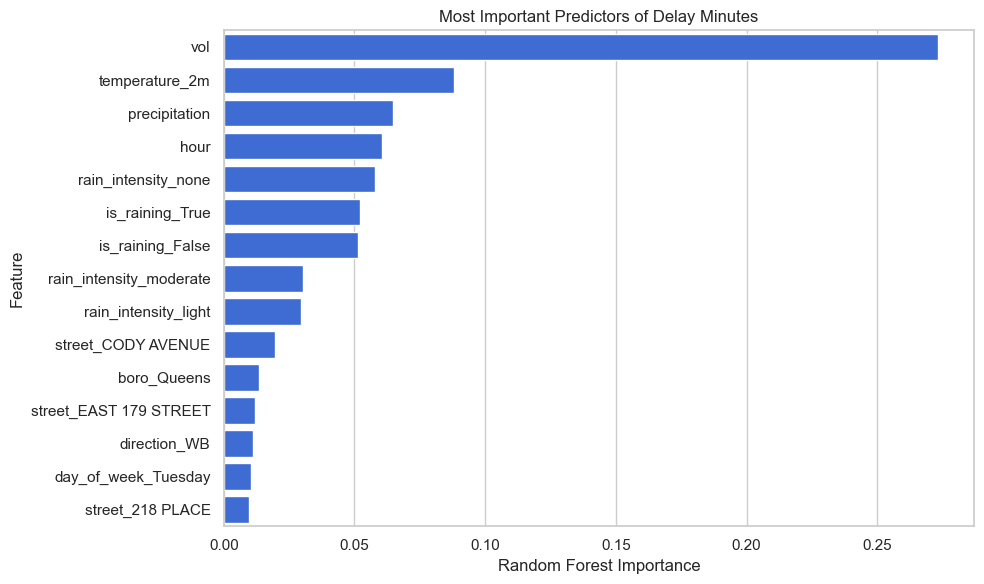

In [33]:
top_importance = importance_df.head(15).copy()

plt.figure(figsize=(10, 6))
sns.barplot(data=top_importance, x="importance", y="clean_feature", color="#2563eb")
plt.title("Most Important Predictors of Delay Minutes")
plt.xlabel("Random Forest Importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()


In [34]:
rain_effect = active_hours_df.groupby("rain_intensity", observed=True).agg(
    records=("delay_minutes", "size"),
    avg_delay_minutes=("delay_minutes", "mean"),
    median_delay_minutes=("delay_minutes", "median"),
    avg_delay_index=("delay_index", "mean"),
    avg_volume=("vol", "mean"),
    avg_precipitation=("precipitation", "mean")
).reset_index()

boro_rain_effect = active_hours_df.groupby(["boro", "rain_intensity"], observed=True).agg(
    records=("delay_minutes", "size"),
    avg_delay_minutes=("delay_minutes", "mean"),
    avg_delay_index=("delay_index", "mean"),
    avg_volume=("vol", "mean"),
    avg_precipitation=("precipitation", "mean")
).reset_index().sort_values("avg_delay_minutes", ascending=False)

display(rain_effect)
display(boro_rain_effect.head(20))


,rain_intensity,records,avg_delay_minutes,median_delay_minutes,avg_delay_index,avg_volume,avg_precipitation
0,heavy,36,13.154444,7.5,1.001285,111.527778,0.212161
1,light,728,8.037321,2.5,1.006367,126.317308,0.015007
2,moderate,198,10.606919,5.0,1.001364,101.267677,0.082995
3,none,5871,5.772265,0.0,1.013462,137.630216,0.000000


,boro,rain_intensity,records,avg_delay_minutes,avg_delay_index,avg_volume,avg_precipitation
11,Queens,heavy,20,13.399500,0.996248,61.600000,0.206299
0,Bronx,heavy,12,13.184167,1.015098,138.666667,0.211286
7,Manhattan,heavy,4,11.840000,0.985035,279.750000,0.244094
2,Bronx,moderate,61,10.779016,1.006220,97.672131,0.077707
5,Brooklyn,moderate,17,10.715294,1.001792,190.823529,0.090783
9,Manhattan,moderate,11,10.679091,0.996204,250.090909,0.097709
13,Queens,moderate,109,10.486422,0.999100,74.293578,0.083255
12,Queens,light,261,8.276782,1.024925,109.643678,0.013606
4,Brooklyn,light,195,7.987846,0.995601,151.328205,0.012659
8,Manhattan,light,90,7.928667,1.001578,159.533333,0.010324


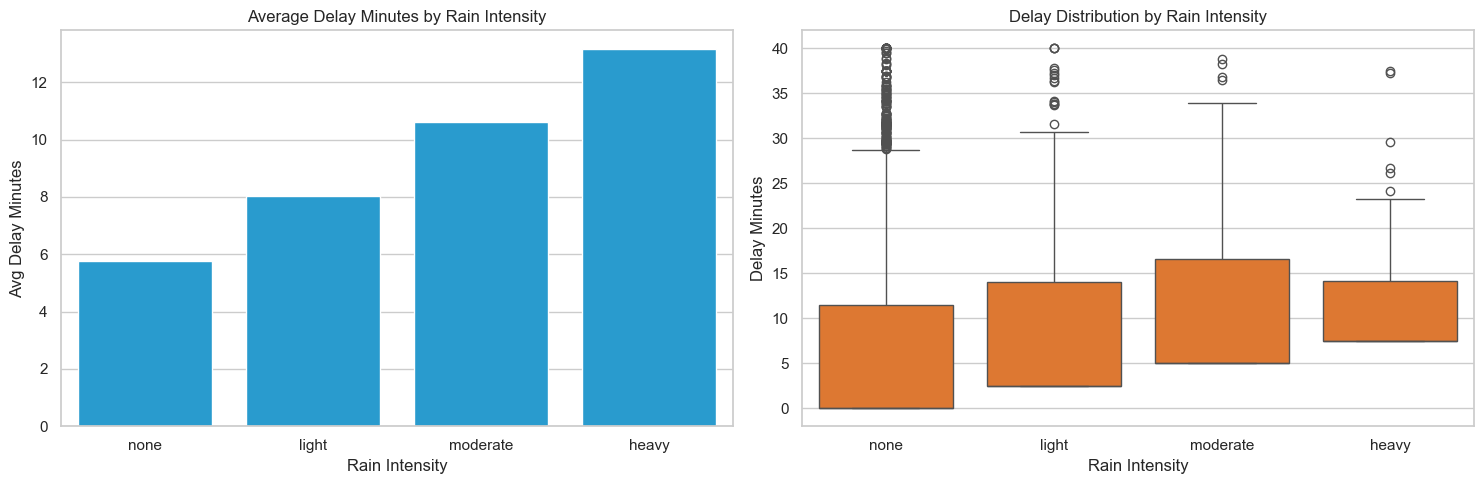

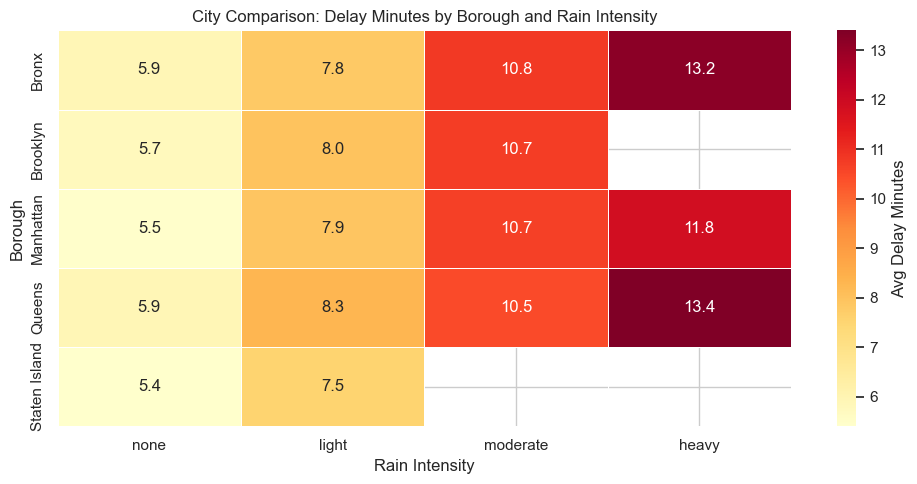

In [35]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

rain_order = ["none", "light", "moderate", "heavy"]
sns.barplot(data=rain_effect, x="rain_intensity", y="avg_delay_minutes", order=rain_order, ax=axes[0], color="#0ea5e9")
axes[0].set_title("Average Delay Minutes by Rain Intensity")
axes[0].set_xlabel("Rain Intensity")
axes[0].set_ylabel("Avg Delay Minutes")

sns.boxplot(data=active_hours_df, x="rain_intensity", y="delay_minutes", order=rain_order, ax=axes[1], color="#f97316")
axes[1].set_title("Delay Distribution by Rain Intensity")
axes[1].set_xlabel("Rain Intensity")
axes[1].set_ylabel("Delay Minutes")

plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 5))
sns.heatmap(
    boro_rain_effect.pivot(index="boro", columns="rain_intensity", values="avg_delay_minutes").reindex(columns=rain_order),
    annot=True,
    fmt=".1f",
    cmap="YlOrRd",
    linewidths=0.5,
    cbar_kws={"label": "Avg Delay Minutes"}
)
plt.title("City Comparison: Delay Minutes by Borough and Rain Intensity")
plt.xlabel("Rain Intensity")
plt.ylabel("Borough")
plt.tight_layout()
plt.show()


In [36]:
rush_scored = active_hours_df.copy()
rush_scored["predicted_delay_minutes"] = weather_model.predict(rush_scored[weather_features]).clip(min=0)
rush_scored["prediction_error_minutes"] = rush_scored["delay_minutes"] - rush_scored["predicted_delay_minutes"]
rush_scored["delay_level"] = pd.cut(
    rush_scored["predicted_delay_minutes"],
    bins=[-0.001, 5, 15, 30, float("inf")],
    labels=["Low", "Moderate", "High", "Severe"]
)

precip_thresholds = sorted(rush_scored["precipitation"].dropna().unique())
precip_thresholds = [x for x in precip_thresholds if x > 0]

threshold_rows = []
for threshold in precip_thresholds:
    lower = rush_scored[rush_scored["precipitation"] < threshold]
    upper = rush_scored[rush_scored["precipitation"] >= threshold]
    if len(lower) >= 100 and len(upper) >= 100:
        threshold_rows.append({
            "precipitation_threshold": threshold,
            "below_avg_predicted_delay_minutes": lower["predicted_delay_minutes"].mean(),
            "above_avg_predicted_delay_minutes": upper["predicted_delay_minutes"].mean(),
            "delay_minute_jump": upper["predicted_delay_minutes"].mean() - lower["predicted_delay_minutes"].mean(),
            "below_records": len(lower),
            "above_records": len(upper)
        })

precip_tipping = pd.DataFrame(
    threshold_rows,
    columns=[
        "precipitation_threshold",
        "below_avg_predicted_delay_minutes",
        "above_avg_predicted_delay_minutes",
        "delay_minute_jump",
        "below_records",
        "above_records",
    ]
).sort_values("delay_minute_jump", ascending=False)
display(precip_tipping.head(10))

display(rush_scored[["date", "hour", "boro", "street", "precipitation", "rain_intensity", "delay_minutes", "predicted_delay_minutes", "delay_level"]].head())


,precipitation_threshold,below_avg_predicted_delay_minutes,above_avg_predicted_delay_minutes,delay_minute_jump,below_records,above_records
17,0.070866,6.188522,10.683827,4.495306,6669,164
13,0.055118,6.148537,10.639409,4.490872,6608,225
12,0.051181,6.142711,10.630971,4.488260,6599,234
14,0.059055,6.161376,10.640563,4.479187,6627,206
18,0.074803,6.194222,10.670365,4.476143,6677,156
16,0.066929,6.181588,10.639570,4.457981,6657,176
15,0.062992,6.176548,10.627875,4.451327,6649,184
19,0.078740,6.207461,10.644064,4.436602,6696,137
20,0.086614,6.210895,10.637799,4.426904,6701,132
21,0.090551,6.224290,10.624526,4.400236,6721,112


,date,hour,boro,street,precipitation,rain_intensity,delay_minutes,predicted_delay_minutes,delay_level
0,2023-11-15,20,Brooklyn,AVENUE J,0.0,none,7.50,5.706543,Moderate
1,2023-11-15,21,Brooklyn,AVENUE J,0.0,none,0.00,5.782074,Moderate
2,2023-11-15,21,Brooklyn,AVENUE J,0.0,none,15.07,5.899350,Moderate
3,2023-11-15,21,Brooklyn,AVENUE J,0.0,none,4.32,5.771673,Moderate
4,2023-11-15,21,Brooklyn,AVENUE J,0.0,none,0.00,5.782006,Moderate


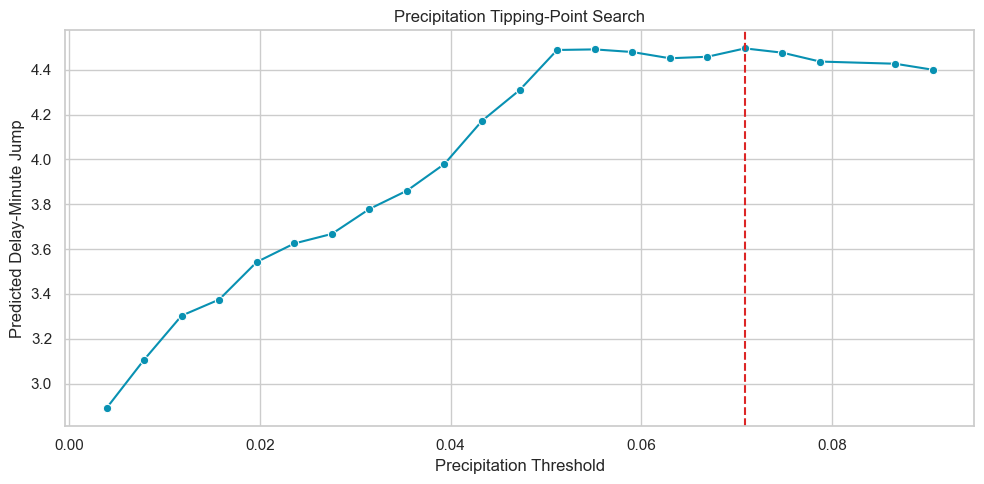

In [37]:
plt.figure(figsize=(10, 5))

if len(precip_tipping):
    precip_plot = precip_tipping.sort_values("precipitation_threshold")
    sns.lineplot(data=precip_plot, x="precipitation_threshold", y="delay_minute_jump", marker="o", color="#0891b2")
    best_precip = precip_tipping.iloc[0]
    plt.axvline(best_precip["precipitation_threshold"], color="#dc2626", linestyle="--")
    plt.title("Precipitation Tipping-Point Search")
    plt.xlabel("Precipitation Threshold")
    plt.ylabel("Predicted Delay-Minute Jump")
else:
    plt.text(0.5, 0.5, "No reliable precipitation tipping point", ha="center", va="center")
    plt.axis("off")

plt.tight_layout()
plt.show()


In [38]:
benchmark_metrics = model_results.set_index("model").loc["mean_delay_benchmark"]
baseline_metrics = model_results.set_index("model").loc["baseline_volume_time_location"]
precip_metrics = model_results.set_index("model").loc["precipitation_aware"]

baseline_rmse_vs_mean = baseline_metrics["rmse"] - benchmark_metrics["rmse"]
precip_rmse_vs_baseline = precip_metrics["rmse"] - baseline_metrics["rmse"]
precip_mae_vs_baseline = precip_metrics["mae"] - baseline_metrics["mae"]
precip_r2_vs_baseline = precip_metrics["r2"] - baseline_metrics["r2"]
best_precip_threshold = precip_tipping.iloc[0] if len(precip_tipping) else None

print("Q1: What is the relationship between precipitation and estimated delay time?")
display(rain_effect)

print("Q2: Does traffic volume fix the weak-delay prediction problem?")
print(f"Volume baseline RMSE change vs mean benchmark: {baseline_rmse_vs_mean:.3f} minutes (negative is better)")
print(f"Volume baseline R-squared: {baseline_metrics['r2']:.3f}")

print("Q3: Does precipitation improve delay-time regression after volume/time/location are included?")
print(f"Precipitation model RMSE change vs volume baseline: {precip_rmse_vs_baseline:.3f} minutes (negative is better)")
print(f"Precipitation model MAE change vs volume baseline: {precip_mae_vs_baseline:.3f} minutes (negative is better)")
print(f"Precipitation model R-squared change vs volume baseline: {precip_r2_vs_baseline:.3f} (positive is better)")

print("Q4: Which weather condition creates the sharpest delay increase?")
if best_precip_threshold is not None:
    print(f"Strongest precipitation tipping candidate: >= {best_precip_threshold['precipitation_threshold']:.3f}, predicted delay jump {best_precip_threshold['delay_minute_jump']:.2f} minutes")
else:
    print("No reliable precipitation tipping point found with enough records on both sides.")

print("Dashboard mapping:")
print("1. Live predictions: rush_scored and tableau_live_predictions")
print("2. City comparison: boro_rain_effect and tableau_city_comparison")
print("3. A/B results: model_results and tableau_ab_results")


Q1: What is the relationship between precipitation and estimated delay time?


,rain_intensity,records,avg_delay_minutes,median_delay_minutes,avg_delay_index,avg_volume,avg_precipitation
0,heavy,36,13.154444,7.5,1.001285,111.527778,0.212161
1,light,728,8.037321,2.5,1.006367,126.317308,0.015007
2,moderate,198,10.606919,5.0,1.001364,101.267677,0.082995
3,none,5871,5.772265,0.0,1.013462,137.630216,0.000000


Q2: Does traffic volume fix the weak-delay prediction problem?
Volume baseline RMSE change vs mean benchmark: -0.074 minutes (negative is better)
Volume baseline R-squared: 0.014
Q3: Does precipitation improve delay-time regression after volume/time/location are included?
Precipitation model RMSE change vs volume baseline: -0.002 minutes (negative is better)
Precipitation model MAE change vs volume baseline: 0.023 minutes (negative is better)
Precipitation model R-squared change vs volume baseline: 0.000 (positive is better)
Q4: Which weather condition creates the sharpest delay increase?
Strongest precipitation tipping candidate: >= 0.071, predicted delay jump 4.50 minutes
Dashboard mapping:
1. Live predictions: rush_scored and tableau_live_predictions
2. City comparison: boro_rain_effect and tableau_city_comparison
3. A/B results: model_results and tableau_ab_results


### Suggested Interpretation

Use `rain_effect` to describe how average delay minutes change from dry to rainy conditions. The `delay_minutes` target is a congestion proxy built from local traffic baselines, volume percentile spikes, IQR-normalized abnormal volume, and precipitation pressure. The model now includes `vol` because actual traffic volume is the core congestion signal. Interpret Model B as a precipitation-aware congestion scoring model, not as proof that weather alone causes delay. Use `model_results` to compare the mean benchmark, Model A (volume/time/location baseline), and Model B (volume/time/location plus weather). Use `boro_rain_effect`, `rush_scored`, and the Tableau export tables to build the required live predictions, city comparison, and A/B results dashboards.


## 8. Tableau Dashboard Tables

Create MySQL tables designed for the three required Tableau dashboards: **live predictions**, **city comparison**, and **A/B results**.


In [39]:
import importlib
import tableau_exports

importlib.reload(tableau_exports)
from tableau_exports import build_tableau_tables, write_tableau_tables

tableau_tables = build_tableau_tables(
    active_hours_df=active_hours_df,
    rush_scored=rush_scored,
    model_results=model_results,
    weather_features=weather_features,
    weather_model=weather_model
)

for table_name, table_df in tableau_tables.items():
    print(f"{table_name}: {table_df.shape[0]:,} rows x {table_df.shape[1]:,} columns")

display(tableau_tables["tableau_live_predictions"].head())
display(tableau_tables["tableau_city_comparison"].head())
display(tableau_tables["tableau_ab_results"])

if "engine" in globals():
    written_tables = write_tableau_tables(engine, tableau_tables)
    print("Written to MySQL:")
    for table_name in written_tables:
        print(f"- {table_name}")
else:
    print("MySQL engine is not defined. Run the database connection cell before writing Tableau tables.")


tableau_live_predictions: 6,833 rows x 29 columns
tableau_live_predictions_by_borough: 5 rows x 9 columns
tableau_city_comparison: 17 rows x 11 columns
tableau_ab_results: 3 rows x 9 columns
tableau_today_weather_predictions: 5 rows x 14 columns


,date,hour,boro,street,fromst,tost,direction,vol,expected_volume,p75_volume,...,delay_minutes,predicted_delay_minutes,delay_level,rain_intensity,temperature_2m,precipitation,is_raining,day_of_week,prediction_error_minutes,is_raining_flag
0,2023-11-15,20,Brooklyn,AVENUE J,East 80 Street,East 81 Street,EB,20,20.0,20.00,...,7.50,5.706543,Moderate,none,45.139999,0.0,False,Wednesday,1.793457,False
1,2023-11-15,21,Brooklyn,AVENUE J,East 80 Street,East 81 Street,EB,15,19.0,23.75,...,0.00,5.782074,Moderate,none,45.950001,0.0,False,Wednesday,-5.782074,False
2,2023-11-15,21,Brooklyn,AVENUE J,East 80 Street,East 81 Street,EB,26,19.0,23.75,...,15.07,5.899350,Moderate,none,45.950001,0.0,False,Wednesday,9.170650,False
3,2023-11-15,21,Brooklyn,AVENUE J,East 80 Street,East 81 Street,EB,23,19.0,23.75,...,4.32,5.771673,Moderate,none,45.950001,0.0,False,Wednesday,-1.451673,False
4,2023-11-15,21,Brooklyn,AVENUE J,East 80 Street,East 81 Street,EB,13,19.0,23.75,...,0.00,5.782006,Moderate,none,45.950001,0.0,False,Wednesday,-5.782006,False


,boro,rain_intensity,records,avg_delay_minutes,avg_predicted_delay_minutes,avg_delay_index,avg_temperature,avg_precipitation,latitude,longitude,delay_level
0,Bronx,heavy,12,13.184167,11.104853,1.015098,59.240002,0.211286,40.8448,-73.8648,Moderate
1,Bronx,light,170,7.819176,8.443912,0.993834,53.367062,0.022371,40.8448,-73.8648,Moderate
2,Bronx,moderate,61,10.779016,10.539326,1.006220,51.229015,0.077707,40.8448,-73.8648,Moderate
3,Bronx,none,1153,5.929714,5.838487,1.017685,57.759827,0.000000,40.8448,-73.8648,Moderate
4,Brooklyn,light,195,7.987846,8.408426,0.995601,55.061234,0.012659,40.6782,-73.9442,Moderate


,model,features,mae,rmse,r2,ab_group,dashboard,recommendation_score,recommendation
0,mean_delay_benchmark,train_mean_only,7.039028,8.768877,-0.003081,Benchmark: mean,A/B results,-8.768877,Compare
1,baseline_volume_time_location,volume_time_location,6.953016,8.694896,0.013773,A: volume baseline,A/B results,-8.694896,Compare
2,precipitation_aware,volume_time_location_weather_precipitation,6.976216,8.692920,0.014222,B: precipitation-aware,A/B results,-8.692920,Recommended


Written to MySQL:
- tableau_live_predictions
- tableau_live_predictions_by_borough
- tableau_city_comparison
- tableau_ab_results
- tableau_today_weather_predictions
